# NLP Zero To Hero Part 3: Training Model to Recognize Sentiment

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
nltk.download('punkt_tab')
import json

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/svenwu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Building a classifier to recognize sentiment in text.

In [3]:
vocab_size = 10000
embedding_dim = 16
max_length = 100
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
training_size = 20000


In [4]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/sarcasm.json \
    -O /tmp/sarcasm.json


--2026-09-11 14:27:15--  https://storage.googleapis.com/learning-datasets/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.108.207, 142.251.121.207, 192.178.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.108.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: '/tmp/sarcasm.json'

/tmp/sarcasm.json   100%[===================>]   5.38M  23.7MB/s    in 0.2s    

2026-09-11 14:27:15 (23.7 MB/s) - '/tmp/sarcasm.json' saved [5643545/5643545]



In [5]:
with open("/tmp/sarcasm.json", 'r') as f:
    datastore = json.load(f)

sentences = []
labels = []
urls = []

for item in datastore:
    sentences.append(item['headline'])
    labels.append(item['is_sarcastic'])
    urls.append(item['article_link'])

In [6]:
tokenizer = Tokenizer(oov_token="<OOV>")
# Calling "fit" on texts with the "Headlines", enables us to create tokens for every word in the corpus.
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index

sequences = tokenizer.texts_to_sequences(sentences)
padded = pad_sequences(sequences, padding='post')
print(padded[0])
# We will get 26709 sequences, each with 40 tokens.
print(padded.shape)

[  308 15115   679  3337  2298    48   382  2576 15116     6  2577  8434
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]
(26709, 40)


### Split into training and testing data.

In [7]:
print(f'Length of sentences: {len(sentences)}')
print(f'Length of labels: {len(labels)}')
print(f'Length of URLs: {len(urls)}')


Length of sentences: 26709
Length of labels: 26709
Length of URLs: 26709


In [8]:
# Training Size of 20000 chosen.
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]

# Same with labels
training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

### Rewrite Code, so it is only FIT TO THE TRAINING DATA.
* Not the testing data.

In [9]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
# Fit tokenizer on just the training sentences.
tokenizer.fit_on_texts(training_sentences)

word_index = tokenizer.word_index

# Create a set of training sequences, and pad them.
training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, 
                                padding=padding_type, truncating=trunc_type)

# Create a set of testing sequences, and pad them.
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, 
                               padding=padding_type, truncating=trunc_type)

### How Do We Derive Meaning From Our Text and Sequence of Numbers?

* How is somthing "sarcastic"?

* Look into embeddings.
  - EX: Sentiment
    - Good or Bad.

    - Plotting a word like "Meh" or "Not bad"

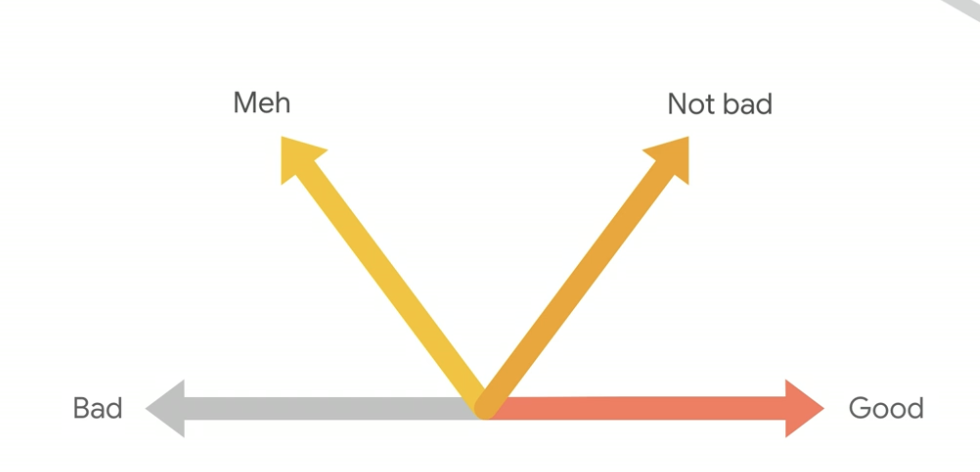

* Now envision as an x and y coordinate plane, and we can start to determine the sentiment with an EMBEDDING VECTOR.

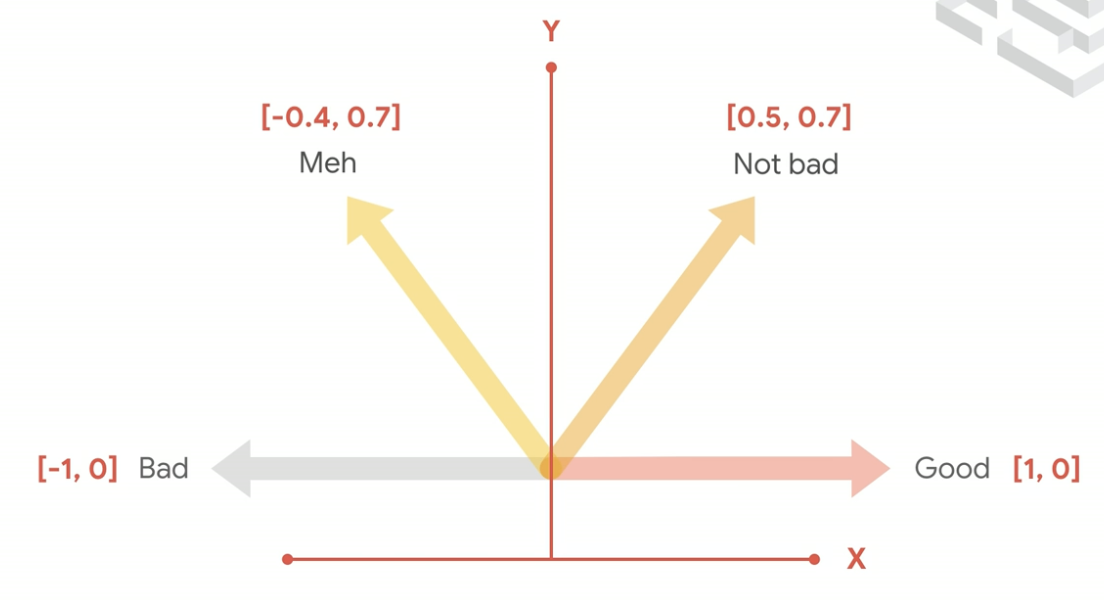

In [10]:
# Need this block to get it to work with TensorFlow 2.x
# CONVERT the four datasets into NumPy ARRAYS:
# This gives Keras/TensorFlow a DATA TYPE it could recognize for model.fit().
import numpy as np
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

In [11]:
# Neutral Network
model = tf.keras.Sequential([
    # Top layer is an EMBEDDING(where the direction of each word will be learned epoch by epoch.)
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    
    # Then pool with a global average pooling (adding up the vectors)
    tf.keras.layers.GlobalAveragePooling1D(),
    
    # This is then fed into a deep neural network.
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/Users/svenwu/Hustle/MachineLearning/venv-tf/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Training with "model.fit" using the training data and labels.
num_epochs = 30
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 2s - 3ms/step - accuracy: 0.5613 - loss: 0.6831 - val_accuracy: 0.5633 - val_loss: 0.6727
Epoch 2/30
625/625 - 1s - 2ms/step - accuracy: 0.6965 - loss: 0.5796 - val_accuracy: 0.8086 - val_loss: 0.4659
Epoch 3/30
625/625 - 1s - 2ms/step - accuracy: 0.8174 - loss: 0.4158 - val_accuracy: 0.7971 - val_loss: 0.4252
Epoch 4/30
625/625 - 1s - 2ms/step - accuracy: 0.8408 - loss: 0.3615 - val_accuracy: 0.8393 - val_loss: 0.3767
Epoch 5/30
625/625 - 1s - 2ms/step - accuracy: 0.8688 - loss: 0.3148 - val_accuracy: 0.8269 - val_loss: 0.3791
Epoch 6/30
625/625 - 1s - 2ms/step - accuracy: 0.8806 - loss: 0.2901 - val_accuracy: 0.8140 - val_loss: 0.3993
Epoch 7/30
625/625 - 1s - 2ms/step - accuracy: 0.8928 - loss: 0.2632 - val_accuracy: 0.8539 - val_loss: 0.3445
Epoch 8/30
625/625 - 1s - 2ms/step - accuracy: 0.8957 - loss: 0.2551 - val_accuracy: 0.8320 - val_loss: 0.3730
Epoch 9/30
625/625 - 1s - 2ms/step - accuracy: 0.9062 - loss: 0.2301 - val_accuracy: 0.8307 - val_loss: 0.3943
E

In [ ]:
# %pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


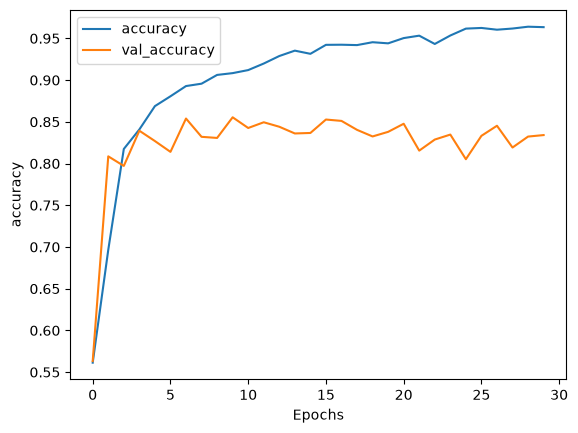

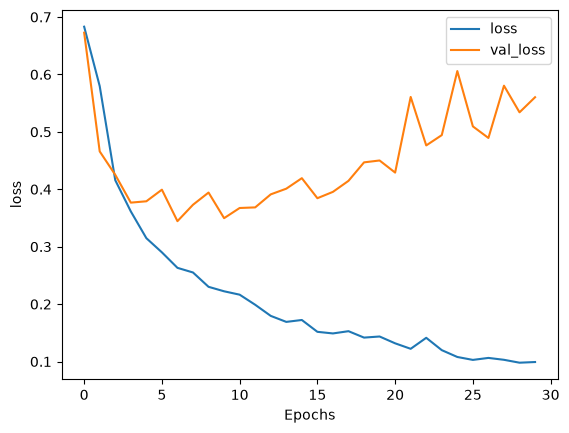

In [15]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()
  
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

### Sentiment for New Sentences

In [17]:
sentence = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"]
sequences = tokenizer.texts_to_sequences(sentence)
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
# First sentence is 0.96, close to 1, so indicates high level of sarcasm.
# Second sentence is 0.04, close to 0, so indicates low level of sarcasm.

print(model.predict(padded))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[0.9635934 ]
 [0.04979232]]
